# **Guía de Actividades Práctico-Experimentales Nro. 012**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Práctica Nro.** | 012 |
| **Título de la Práctica** | **Análisis Bivariado y Predicción: Correlación de Pearson y Modelo de Regresión Lineal Simple (OLS)**|
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Lunes 20 de julio 2026 |

---



# **Objetivos de Aprendizaje**

*   Cuantificar la fuerza y dirección de la relación lineal entre dos variables continuas mediante el Coeficiente de Correlación de Pearson ($r$).  
*   Construir y ajustar un modelo de Regresión Lineal Simple basado en el método de Mínimos Cuadrados Ordinarios (OLS) usando statsmodels.  
*   Investigar y validar estadísticamente los supuestos de los residuos (normalidad y homocedasticidad) para garantizar la fiabilidad del modelo.  

# **Tarea 1: Análisis de Correlación de Pearson**

--- Análisis de Correlación de Pearson ---
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


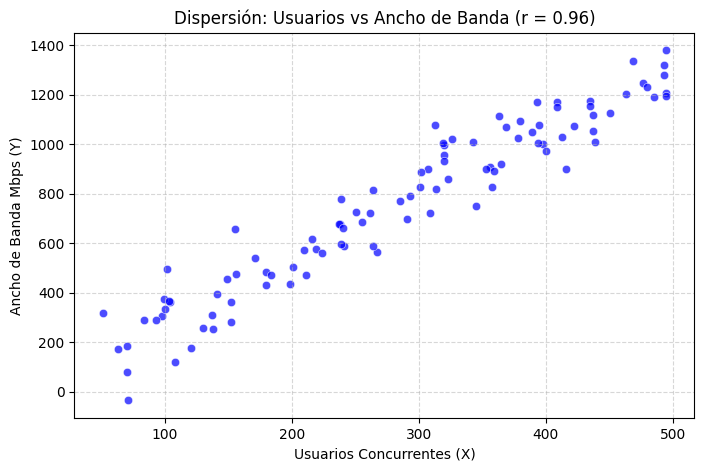

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)
# Y = 2.5*X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 1. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("--- Análisis de Correlación de Pearson ---")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
    print("Conclusión: NO existe evidencia de correlación lineal significativa.")

# 2. Visualización: Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)
plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# **Tarea 2: Ajuste del Modelo de Regresión Lineal Simple (OLS)**

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        12:57:22   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

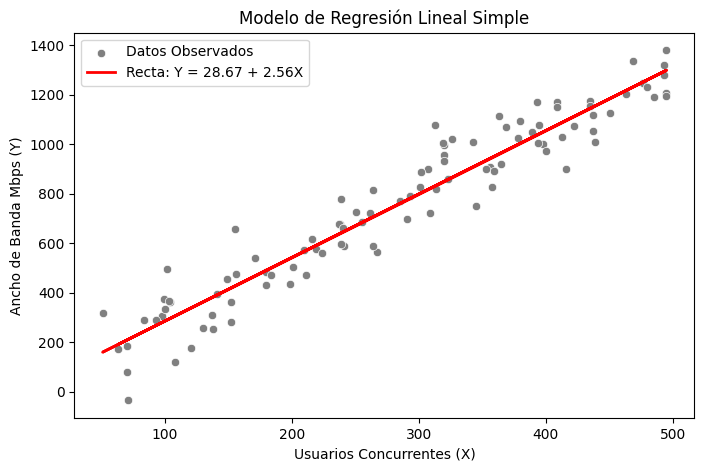

In [2]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) al predictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')
# Dibujo de la recta de regresión
plt.plot(usuarios_X, beta_0 + beta_1 * usuarios_X, color='red', linewidth=2, label=f'Recta: Y = {beta_0:.2f} + {beta_1:.2f}X')
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()


# Tarea 3: Hito del Proyecto - Predicción en el Dataset Regional (ABP)

**Dataset:** Global Forest Watch - Pérdida de cobertura arbórea, provincia de Loja (Ecuador)

**X (predictora):** Año
**Y (respuesta):** Pérdida de cobertura arbórea (hectáreas)


## Paso 1: Importar el dataset

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Cargar el dataset
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'
df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
display(df.head(15))
df = df.dropna(how='all').reset_index(drop=True)

,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,...,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024
0,Ecuador,Azuay,0,816926,816926,816926,5887,1859,340,342,...,370,606,457,289,347,272,189,322,291,385
1,Ecuador,Azuay,10,816926,428633,484716,5887,1804,337,331,...,351,557,416,269,304,249,152,258,202,285
2,Ecuador,Azuay,15,816926,409481,472186,5887,1801,335,329,...,347,548,409,265,299,244,149,248,192,272
3,Ecuador,Azuay,20,816926,398952,464049,5887,1788,334,328,...,344,545,405,263,297,243,148,246,188,267
4,Ecuador,Azuay,25,816926,391864,450921,5887,1781,334,327,...,343,541,403,261,296,242,145,244,186,263
5,Ecuador,Azuay,30,816926,383423,435249,5887,1776,333,324,...,341,537,400,259,294,241,143,240,183,259
6,Ecuador,Azuay,50,816926,316850,328208,5887,1686,324,300,...,320,495,368,242,275,218,130,213,155,219
7,Ecuador,Azuay,75,816926,208116,237227,5887,1497,296,256,...,270,377,275,194,192,167,90,146,92,148
8,Ecuador,Bolivar,0,389964,389964,389964,4089,337,371,86,...,163,248,171,327,335,140,79,169,306,268
9,Ecuador,Bolivar,10,389964,253342,261961,4089,332,369,85,...,68,136,98,232,216,80,35,108,187,186


## Paso 2: Identificar variable independiente (X) y dependiente (Y)

El dataset viene en formato ancho (una columna por año: `tc_loss_ha_2001`, `tc_loss_ha_2002`, ..., `tc_loss_ha_2023`).
Para poder hacer una regresión, se filtra la provincia de Loja (threshold=30) y se transforma a formato largo:
cada fila pasa a representar un año.

- **X = Año** (predictora)
- **Y = Pérdida de cobertura arbórea en hectáreas** (respuesta)

In [ ]:
# Filtrar la provincia de Loja con threshold = 30
df_loja = df[(df['subnational1'] == 'Loja') & (df['threshold'] == 30)].copy()

# Identificar las columnas de pérdida por año (tc_loss_ha_XXXX)
year_cols = [c for c in df_loja.columns if c.startswith('tc_loss_ha_')]

# Pasar de formato ancho a formato largo (una fila por año)
df_long = df_loja.melt(id_vars=['subnational1', 'threshold'], value_vars=year_cols,
                        var_name='anio_col', value_name='perdida_ha')
df_long['anio'] = df_long['anio_col'].str.extract(r'(\d{4})').astype(int)
df_long = df_long[['anio', 'perdida_ha']].sort_values('anio').reset_index(drop=True)

X = df_long['anio']
Y = df_long['perdida_ha']

display(df_long)

,anio,perdida_ha
0,2001,1503
1,2002,751
2,2003,858
3,2004,1051
4,2005,915
5,2006,1631
6,2007,1126
7,2008,1061
8,2009,1596
9,2010,675


## Paso 3: Coeficiente de correlación (r), modelo OLS y summary()

### Cumplimiento de Tarea 1: Análisis de Correlación de Pearson y parte de Tarea 2: Ajuste del Modelo OLS

En esta sección, se realiza el cálculo del coeficiente de correlación de Pearson entre el `Año` (X) y la `Pérdida de cobertura arbórea (ha)` (Y), tal como se describe en la Tarea 1. Posteriormente, se ajusta el modelo de Regresión Lineal Simple (OLS) utilizando `statsmodels` como se pide en la Tarea 2, y se imprime su `summary()`.

Coeficiente de correlación r = -0.1438
p-valor de la correlación = 0.5026


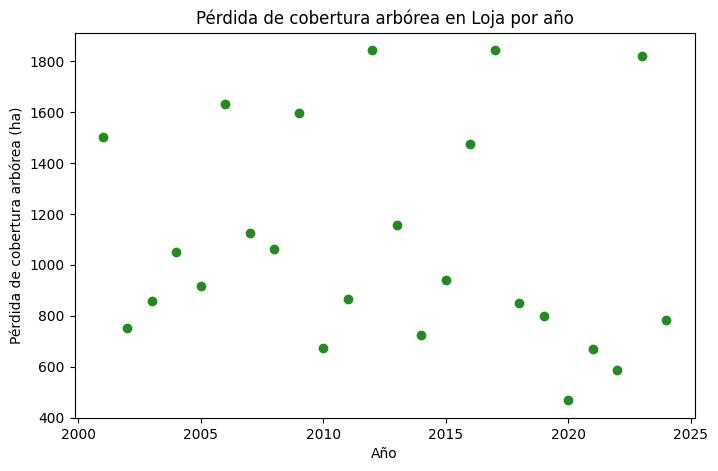

In [ ]:
# Coeficiente de correlación de Pearson
r, p_valor = stats.pearsonr(X, Y)
print(f"Coeficiente de correlación r = {r:.4f}")
print(f"p-valor de la correlación = {p_valor:.4f}")

# Gráfico de dispersión con tendencia
plt.figure(figsize=(8,5))
plt.scatter(X, Y, color='forestgreen')
plt.xlabel('Año')
plt.ylabel('Pérdida de cobertura arbórea (ha)')
plt.title('Pérdida de cobertura arbórea en Loja por año')
plt.show()

In [ ]:
import statsmodels.api as sm

# Ajustar el modelo de regresión lineal OLS
X_ols = sm.add_constant(X)  # agrega la constante (beta0)
modelo = sm.OLS(Y, X_ols).fit()

print(modelo.summary())

print("\n--- Resumen Clave del Modelo ---")

# Extraer coeficientes, p-valores y R-squared
coeficientes = modelo.params
p_valores = modelo.pvalues
r_cuadrado = modelo.rsquared

print(f"R-squared (R²): {r_cuadrado:.4f} (Indica que el {r_cuadrado*100:.1f}% de la variabilidad en 'perdida_ha' es explicada por el 'anio').")
print("\nCoeficientes del Modelo:")
print(f"  Intercepto (constante): {coeficientes['const']:.4f} (p-valor: {p_valores['const']:.4f})")
print(f"  Año (anio):             {coeficientes['anio']:.4f} (p-valor: {p_valores['anio']:.4f})")

if p_valores['anio'] < 0.05:
    print("\nConclusión: El año es un predictor estadísticamente significativo de la pérdida de cobertura arbórea.")
else:
    print("\nConclusión: El año NO es un predictor estadísticamente significativo de la pérdida de cobertura arbórea (el p-valor es mayor a 0.05). Esto significa que la relación lineal observada podría deberse al azar.")

                            OLS Regression Results                            
Dep. Variable:             perdida_ha   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.024
Method:                 Least Squares   F-statistic:                    0.4646
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.503
Time:                        13:23:40   Log-Likelihood:                -178.59
No. Observations:                  24   AIC:                             361.2
Df Residuals:                      22   BIC:                             363.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.852e+04   2.56e+04      0.724      0.4

### Cumplimiento de Tarea 2 (continuación): Predicción

Aquí se extraen los coeficientes (β0 y β1) del modelo OLS previamente ajustado para realizar una predicción manual de la pérdida de cobertura arbórea para un año futuro (`x_critico = 2026`), que no está presente en el dataset original. Esto cumple con la sección de 'Predicción' de la Tarea 2.

## Paso 4: Predicción manual con los coeficientes (β0, β1)

Se toma un año que **no existe** en el dataset original (2001-2023) y se calcula el pronóstico
de pérdida de cobertura arbórea usando la ecuación de la recta: `Y = β0 + β1 * X`

In [ ]:
# Extraer los coeficientes del modelo
beta0 = modelo.params['const']
beta1 = modelo.params['anio']

print(f"β0 (intercepto) = {beta0:.4f}")
print(f"β1 (pendiente)  = {beta1:.4f}")

# Valor crítico de X que no existe en el dataset original (pronóstico)
x_critico = 2026

# Cálculo manual: Y = β0 + β1 * X
y_pred = beta0 + beta1 * x_critico

print(f"\nPredicción manual para el año {x_critico}:")
print(f"Y = {beta0:.4f} + ({beta1:.4f} * {x_critico})")
print(f"Y estimado = {y_pred:.2f} hectáreas de pérdida de cobertura arbórea")

β0 (intercepto) = 18515.4167
β1 (pendiente)  = -8.6622

Predicción manual para el año 2026:
Y = 18515.4167 + (-8.6622 * 2026)
Y estimado = 965.85 hectáreas de pérdida de cobertura arbórea


## Paso 5: Interpretación del R-squared desde la perspectiva del negocio

In [ ]:
r2 = modelo.rsquared
print(f"R-squared del modelo = {r2:.4f}  ({r2*100:.1f}%)")

if r2 >= 0.7:
    nivel = "alto"
elif r2 >= 0.4:
    nivel = "moderado"
else:
    nivel = "bajo"

print(f"""
Interpretación de negocio:

El modelo indica que el {r2*100:.1f}% de la variabilidad en la pérdida de cobertura arbórea
de la provincia de Loja se explica únicamente por el paso del tiempo (año). Esto representa
un nivel de ajuste {nivel}.

Para la toma de decisiones, esto significa que el año por sí solo {'sí es un buen' if r2 >= 0.5 else 'no es un'}
predictor confiable de cuánta superficie boscosa se perderá. Un R² {nivel} sugiere que, además de la
tendencia temporal, hay otros factores (políticas de conservación, presión agrícola, minería, clima, etc.)
que influyen en la deforestación y que deberían incorporarse en un modelo más completo antes de usar
esta predicción como base única para decisiones de inversión o política pública en la región.
""")

R-squared del modelo = 0.0207  (2.1%)

Interpretación de negocio:

El modelo indica que el 2.1% de la variabilidad en la pérdida de cobertura arbórea
de la provincia de Loja se explica únicamente por el paso del tiempo (año). Esto representa
un nivel de ajuste bajo.

Para la toma de decisiones, esto significa que el año por sí solo no es un 
predictor confiable de cuánta superficie boscosa se perderá. Un R² bajo sugiere que, además de la
tendencia temporal, hay otros factores (políticas de conservación, presión agrícola, minería, clima, etc.)
que influyen en la deforestación y que deberían incorporarse en un modelo más completo antes de usar
esta predicción como base única para decisiones de inversión o política pública en la región.



# **Diagnóstico de Residuos (ABI)**



Test de Shapiro-Wilk sobre los Residuos:
  Estadístico W = 0.8831
  p-valor = 0.0096


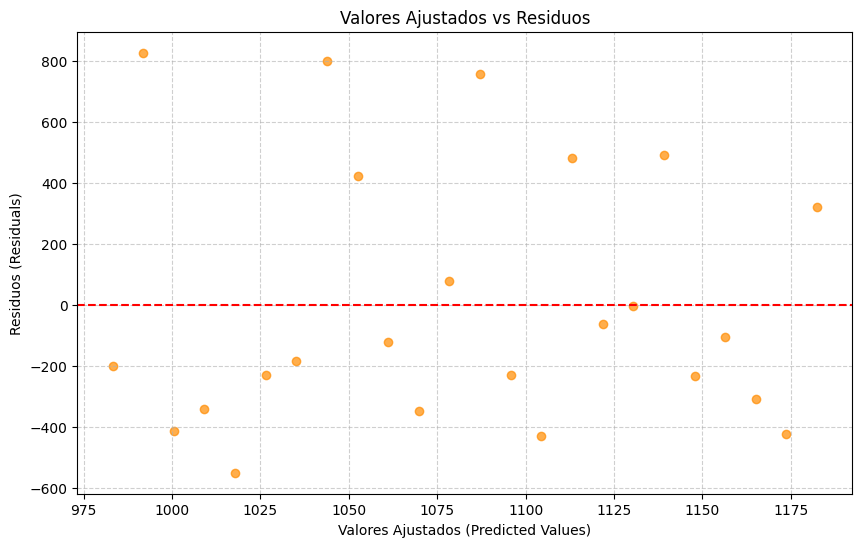

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Obtener los residuos del modelo OLS
residuos = modelo.resid

# Realizar el test de Shapiro-Wilk para normalidad de los residuos
shapiro_test = stats.shapiro(residuos)
print(f"\nTest de Shapiro-Wilk sobre los Residuos:")
print(f"  Estadístico W = {shapiro_test.statistic:.4f}")
print(f"  p-valor = {shapiro_test.pvalue:.4f}")

# Generar el gráfico de dispersión 'Valores Ajustados vs Residuos'
plt.figure(figsize=(10, 6))
plt.scatter(modelo.fittedvalues, residuos, color='darkorange', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados (Predicted Values)')
plt.ylabel('Residuos (Residuals)')
plt.title('Valores Ajustados vs Residuos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Dictamen sobre la validez del modelo (basado en el diagnóstico de residuos)

El **test de Shapiro-Wilk** nos dice si los residuos siguen una distribución normal. Un p-valor bajo (menor a 0.05) indica que no son normales. En nuestro caso:
*   **Estadístico W = 0.8831**
*   **p-valor = 0.0096**

Dado que el p-valor es **0.0096 (menor a 0.05)**, concluimos que los residuos **NO tienen una distribución normal**. Esto incumple una suposición importante del modelo OLS.

El **gráfico de dispersión 'Valores Ajustados vs Residuos'** nos ayuda a ver si hay patrones en los errores del modelo. Idealmente, los puntos deberían estar dispersos al azar alrededor de la línea horizontal de cero. Si vemos un patrón (como una forma de embudo o una curva), significa que el modelo no es adecuado.

En nuestro gráfico, observamos que los residuos:
-   **Muestran una dispersión irregular, no aleatoria.**
-   **No están distribuidos uniformemente alrededor de la línea cero.**

Esto sugiere problemas como que la varianza de los errores no es constante (heterocedasticidad) o que la relación no es lineal.

**Conclusión General sobre la Validez del Modelo:**
Considerando que el R-squared fue muy bajo (2.1%), el año (`anio`) no fue un predictor significativo (p-valor: 0.5026), y ahora vemos que los residuos no son normales y muestran patrones, el modelo lineal simple usando solo el `anio` **no es válido ni adecuado** para predecir la `perdida_ha` en Loja. Necesitamos buscar otras variables y un modelo diferente para tener predicciones confiables.

# **Preguntas de Control**

---

### **1. ¿Cuál es el coeficiente de correlación de Pearson ($r$) entre el Año ($X$) y la Pérdida de Cobertura Arbórea ($Y$) en la provincia de Loja y qué indica sobre la relación entre ambas variables?**

* **Coeficiente de correlación ($r$):** $-0.1438$ (p-valor = $0.5026$).
* **Interpretación:**
  * **Dirección y Fuerza:** El valor $r = -0.1438$ indica una **correlación negativa sumamente débil** (cercana a cero) entre el transcurso de los años y la deforestación en Loja.
  * **Significancia Estadística:** Dado que el p-valor ($0.5026$) es mayor al nivel de significancia $\alpha = 0.05$, **la correlación lineal no es estadísticamente significativa**. No existe evidencia para afirmar que la pérdida de cobertura arbórea aumente o disminuya de forma lineal a lo largo del tiempo.

---

### **2. ¿Qué porcentaje de la variabilidad en la pérdida de cobertura arbórea es explicado por el tiempo (Año) según el modelo OLS ajustado?**

* **Coeficiente de Determinación ($R^2$):** $0.0207$ ($2.1\%$).
* **Interpretación:**
  * El tiempo (Año) explica **únicamente el $2.1\%$ de la variabilidad total** de la pérdida de cobertura arbórea en Loja. El $97.9\%$ restante depende de factores externos no incluidos en el modelo.
  * **Implicación práctica:** El año por sí solo **no es un buen predictor**. La deforestación responde a dinámicas complejas (cambio de uso de suelo, incendios, expansión agrícola, variabilidad climática) que requieren modelos multivariados.

---

### **3. Escriba la ecuación de la recta de regresión ajustada y detalle el valor estimado ($\hat{Y}$) de pérdida de cobertura arbórea para el año 2026.**

* **Parámetros del modelo:**
  * Intercepto ($\beta_0$): $18515.4167$
  * Pendiente ($\beta_1$): $-8.6622$
* **Ecuación de la recta:**
  $$\hat{Y} = 18515.4167 - 8.6622 \cdot X$$

* **Predicción para el año $2026$ ($X = 2026$):**
  $$\hat{Y}_{2026} = 18515.4167 + (-8.6622 \times 2026)$$
  $$\hat{Y}_{2026} = 965.85 \text{ hectáreas}$$

---

### **4. Con base en el diagnóstico de los residuos (Test de Shapiro-Wilk y gráfico de residuos), ¿es válido el modelo de Regresión Lineal Simple para realizar inferencias? Justifique.**

* **Resultados de la prueba Shapiro-Wilk:**
  * Estadístico $W = 0.8831$
  * p-valor $= 0.0096$
* **Dictamen:** **El modelo NO es estadísticamente válido para realizar inferencias.**
* **Justificación:** Dado que el p-valor ($0.0096$) es **menor que $0.05$**, se rechaza la hipótesis nula de normalidad, concluyendo que **los residuos no se distribuyen de forma normal**. Al incumplirse este supuesto fundamental del modelo OLS, las inferencias estadísticas (pruebas de hipótesis, p-valores e intervalos de confianza) no son confiables.

# **Conclusiones de la práctica:**


1. **Divergencia entre modelos teóricos y datos empíricos:**  
   Mientras que en datos simulados con relación directa se obtienen coeficientes elevados ($r > 0.95$, $R^2 > 0.90$), el análisis de datos reales de deforestación (Global Forest Watch) demostró que el tiempo por sí solo no presenta una tendencia lineal clara
   $r = -0.1438$, $R^2 = 0.0207$.

2. **Importancia de la verificación de supuestos en la modelación:**  
   El proceso de regresión no finaliza con la estimación de parámetros ($\beta_0, \beta_1$). El análisis de diagnóstico mediante Shapiro-Wilk $p = 0.0096$ evidenció la violación del supuesto de normalidad en los residuos, demostrando que no se deben realizar inferencias o proyecciones sin antes aplicar transformaciones de datos o recurrir a métodos no paramétricos.

3. **Toma de decisiones basada en evidencia en el ámbito ambiental:**  
   Para la gestión ambiental y el diseño de políticas públicas en la provincia de Loja, los resultados indican que no se pueden aplicar modelos predictivos simplistas basados únicamente en el año. Es indispensable incorporar covariables explicativas reales como incendios forestales, expansión agropecuaria y factores sociodemográficos.

# **Declaración de uso de IA**

**Link del chat con IA utilizado para este APE012:** https://share.gemini.google/aH9zFmSqgg8b